In [21]:
!pip install -Uq pymcel

In [22]:
!pip install -Uq rebound

In [23]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import rebound as rb
from astroquery.jplhorizons import Horizons
from astropy.time import Time

Consultando trayectoria desde 2025-05-08 hasta 2026-05-08...


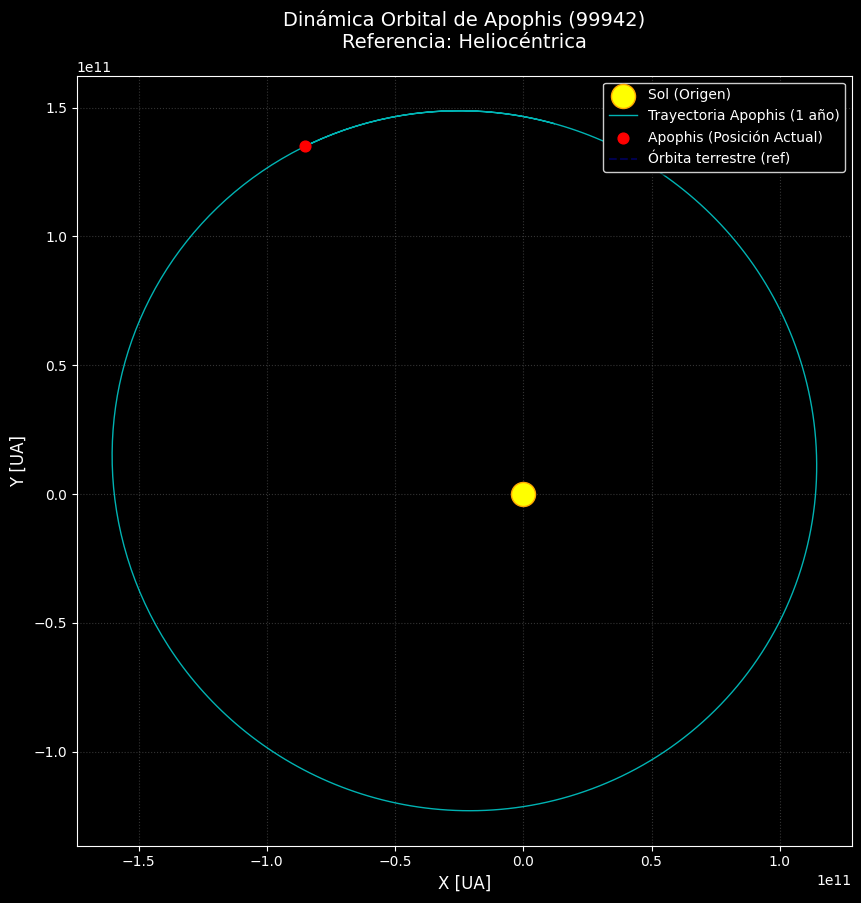

In [24]:
# 1. Configuración de fechas (Desde hoy hasta un año atrás)
# Usamos la fecha actual del sistema (2026)
fecha_final = datetime.now()
fecha_inicio = fecha_final - timedelta(days=365)

# Formateo de fechas para la consulta a JPL Horizons
start_str = fecha_inicio.strftime('%Y-%m-%d')
stop_str = fecha_final.strftime('%Y-%m-%d')

print(f"Consultando trayectoria desde {start_str} hasta {stop_str}...")

# 2. Consulta a JPL Horizons
# ID de Apophis: 99942
# location='@Sun' pone al Sol en el origen (0,0,0)
tabla, jd, X_raw = pc.consulta_horizons(
    id='99942',
    location='@Sun',
    epochs={'start': start_str, 'stop': stop_str, 'step': '1d'}
)

# 3. CORRECCIÓN DEL ERROR: Convertir a array de NumPy para evitar InvalidIndexError
X_total = np.array(X_raw)

# Extraer posiciones X e Y (están en las primeras dos columnas)
x_apophis = X_total[:, 0]
y_apophis = X_total[:, 1]

# 4. Generación de la gráfica 2D
plt.figure(figsize=(10, 10))
plt.style.use('dark_background') # Fondo espacial

# Dibujar al Sol en el centro
plt.scatter(0, 0, color='yellow', s=300, label='Sol (Origen)', edgecolors='orange', zorder=5)

# Dibujar la "estela" (toda la trayectoria del año)
plt.plot(x_apophis, y_apophis, color='cyan', linestyle='-', linewidth=1, alpha=0.7, label='Trayectoria Apophis (1 año)')

# Dibujar la posición actual de Apophis (el último punto registrado)
plt.scatter(x_apophis[-1], y_apophis[-1], color='red', s=60, label='Apophis (Posición Actual)', zorder=6)

# Añadir la órbita de la Tierra como referencia (Círculo de radio 1 UA aprox.)
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), color='blue', linestyle='--', alpha=0.3, label='Órbita terrestre (ref)')

# Personalización técnica de la gráfica
plt.title(f'Dinámica Orbital de Apophis (99942)\nReferencia: Heliocéntrica', fontsize=14, pad=20)
plt.xlabel('X [UA]', fontsize=12)
plt.ylabel('Y [UA]', fontsize=12)
plt.axis('equal') # Crucial para no deformar la elipse de la órbita
plt.grid(color='gray', linestyle=':', alpha=0.4)
plt.legend(loc='upper right', frameon=True, shadow=True)

In [95]:
fecha_inicio = '2026-03-11'

sim = rb.Simulation()
sim.units = ('yr', 'AU', 'Msun')
sim.add('Sun',date= fecha_inicio)
sim.add('Apophis',date= fecha_inicio)


Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 MN4) 


/usr/local/lib/python3.12/dist-packages/rebound/horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


In [96]:
ts = np.linspace(0, 3.01, 100)
pos_apophis_helio1 = np.zeros((100, 3))


for i, t in enumerate(ts):
    sim.integrate(t)

    # Extraemos las partículas
    sol = sim.particles[0]
    apophis = sim.particles[1]

    # Calculamos la posición relativa (Heliocéntrica)
    x_rel = apophis.x - sol.x
    y_rel = apophis.y - sol.y
    z_rel = apophis.z - sol.z

    # Guardamos en nuestro arreglo
    pos_apophis_helio1[i] = [x_rel, y_rel, z_rel]


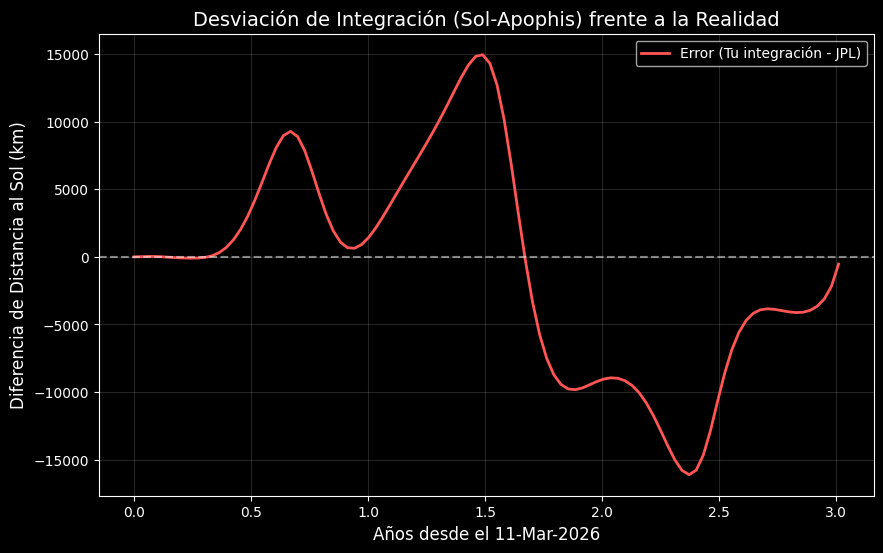

In [99]:
r_rebound_mag1 = np.linalg.norm(pos_apophis_helio1, axis=1)

# 2. Convertir tu tiempo 'ts' a Julian Dates (JD) para el JPL
# integración está en años (yr = 365.25 días)
jd_inicial = Time(fecha_inicio).jd
jds_integracion = jd_inicial + (ts * 365.25)

# 3. Descargar datos del JPL Horizons usando tus tiempos exactos
r_jpl_mag = []

# Dividimos tus 100 tiempos en dos bloques de 50
bloques_jd = [jds_integracion[:50], jds_integracion[50:]]

for bloque in bloques_jd:
    obj = Horizons(id='Apophis', location='@sun', epochs=bloque.tolist())
    vectores = obj.vectors()
    # Guardamos la columna 'range' (distancia al Sol)
    r_jpl_mag.extend(vectores['range'])

r_jpl_mag = np.array(r_jpl_mag)

# 4. Calcular la resta uno a uno (código vs Realidad)
diferencia1 = (r_rebound_mag1 - r_jpl_mag) * 1.5e8

# 5. Generar la gráfica
plt.figure(figsize=(10, 6))
plt.plot(ts, diferencia1, color='#FF5555', linewidth=2, label='Error (Integración - JPL)')
plt.axhline(0, color='white', linestyle='--', alpha=0.5)

plt.title("Desviación de Integración (Sol-Apophis) frente a la Realidad", fontsize=14)
plt.xlabel("Años desde el 11-Mar-2026", fontsize=12)
plt.ylabel("Diferencia de Distancia al Sol (km)", fontsize=12)
plt.grid(True, alpha=0.15)
plt.legend()
plt.style.use('dark_background')
plt.show()

In [107]:
sim2 = rb.Simulation()
sim2.units = ('yr', 'AU', 'Msun')
sim2.add('Sun',date = fecha_inicio)
sim2.add('Apophis',date = fecha_inicio)
sim2.add('Jupiter', date = fecha_inicio)
sim2.add('Saturn', date = fecha_inicio)
sim2.add('Earth', date = fecha_inicio)
sim2.add('Venus', date = fecha_inicio)


sim2.move_to_com()

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 MN4) 
Searching NASA Horizons for 'Jupiter'... 


/usr/local/lib/python3.12/dist-packages/rebound/horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


Found: Jupiter Barycenter (5) (chosen from query 'Jupiter')
Searching NASA Horizons for 'Saturn'... 
Found: Saturn Barycenter (6) (chosen from query 'Saturn')
Searching NASA Horizons for 'Earth'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for 'Venus'... 
Found: Venus Barycenter (299) (chosen from query 'Venus')


In [108]:
pos_apophis_helio2 = np.zeros((100, 3))

for i, t in enumerate(ts):
    sim2.integrate(t)

    # Extraemos las partículas
    sol = sim2.particles[0]
    apophis = sim2.particles[1]

    # Calculamos la posición relativa (Heliocéntrica)
    x_rel = apophis.x - sol.x
    y_rel = apophis.y - sol.y
    z_rel = apophis.z - sol.z

    # Guardamos en nuestro arreglo
    pos_apophis_helio2[i] = [x_rel, y_rel, z_rel]

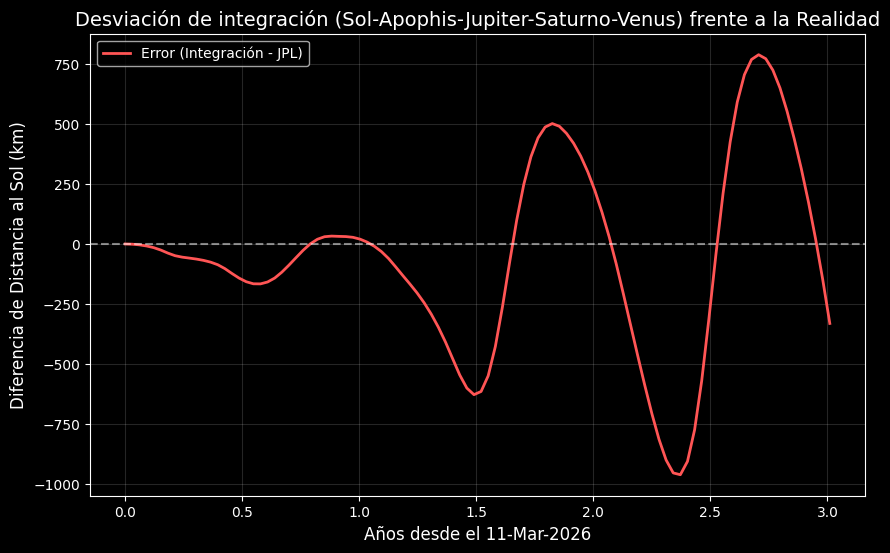

In [112]:
r_rebound_mag = np.linalg.norm(pos_apophis_helio2, axis=1)

# 4. Calcular la resta uno a uno (código vs Realidad)
diferencia2 = (r_rebound_mag - r_jpl_mag) * 1.5e8

# 5. Generar la gráfica
plt.figure(figsize=(10, 6))
plt.plot(ts, diferencia2, color='#FF5555', linewidth=2, label='Error (Integración - JPL)')
plt.axhline(0, color='white', linestyle='--', alpha=0.5)

plt.title("Desviación de integración (Sol-Apophis-Jupiter-Saturno-Venus) frente a la Realidad", fontsize=14)
plt.xlabel("Años desde el 11-Mar-2026", fontsize=12)
plt.ylabel("Diferencia de Distancia al Sol (km)", fontsize=12)
plt.grid(True, alpha=0.15)
plt.legend()
plt.style.use('dark_background')
plt.show()